# A. Install

In [1]:
!pip install -q timm==1.0.3 scikit-learn

import torch
print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())
print("GPU     :", torch.cuda.get_device_name(0))
print("VRAM    :", round(torch.cuda.get_device_properties(0).total_memory/1e9, 1), "GB")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 71.8 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[

# B. Copy code files

In [2]:
import shutil, os, sys

SRC = "/kaggle/input/datasets/nirjanashrestha4/nirjanashresthacode"
DST = "/kaggle/working/src"
os.makedirs(DST, exist_ok=True)

for f in ["model.py", "dataset.py", "train.py",
          "model_ablation.py", "train_ablation.py"]:
    src = f"{SRC}/{f}"
    dst = f"{DST}/{f}"
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"Copied {f}")
    else:
        print(f"MISSING — {f}")

sys.path.insert(0, DST)
print("Done")

Copied model.py
Copied dataset.py
Copied train.py
Copied model_ablation.py
Copied train_ablation.py
Done


# C. Train

## 1. Training loop

In [3]:
import argparse, gc, sys, os, shutil, torch

gc.collect()
torch.cuda.empty_cache()
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

for mod in ['train', 'model', 'dataset']:
    if mod in sys.modules:
        del sys.modules[mod]
sys.path.insert(0, '/kaggle/working/src')

from train import train

cfg = argparse.Namespace(
    cbis_root       = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset",
    vindr_root      = "/kaggle/input/datasets/nirjanashrestha4/vindr-annotations",
    vindr_images    = "/kaggle/input/datasets/shantanughosh/vindr-mammogram-dataset-dicom-to-png/images_png",
    vindr_labels    = "/kaggle/input/datasets/nirjanashrestha4/vindr-annotations",
    save_dir        = "/kaggle/working/checkpoints",
    img_size        = 224,
    batch_size      = 8,
    grad_accum      = 4,
    num_workers     = 4,
    seed            = 42,
    epochs          = 100,
    patience        = 10,
    lr              = 1e-4,
    weight_decay    = 1e-2,
    pos_weight      = 3.0,
    label_smoothing = 0.0,
    wandb           = False,
)

train(cfg)

Device     : cuda
Epochs     : 100  |  patience=10
pos_weight : 3.0

Building dataloaders ...
[CBIS-DDSM] Loaded mass_case_description_train_set.csv  (1318 rows)
[CBIS-DDSM] Loaded mass_case_description_test_set.csv  (378 rows)
[CBIS-DDSM] Loaded calc_case_description_train_set.csv  (1546 rows)
[CBIS-DDSM] Loaded calc_case_description_test_set.csv  (326 rows)
[CBIS-DDSM] Combined: 3568 rows
[CBIS-DDSM] Indexing JPEG images ...
[CBIS-DDSM] Indexed 6,774 JPEG files
[CBIS-DDSM] Full mammogram series: 2857
[CBIS-DDSM] Full mammogram images indexed: 2857
[CBIS-DDSM] Rows with resolved paths: 3286
[CBIS-DDSM] Complete 4-view cases: 94  Benign=63  Malignant=31
[VinDr-Mammo] Loaded breast-level_annotations.csv  (20,000 rows)
[VinDr-Mammo] After BI-RADS filter: 20,000 rows  Benign=19012  Malignant=988
[VinDr-Mammo] Sides: ['LEFT', 'RIGHT']
[VinDr-Mammo] Views: ['CC', 'MLO']
[VinDr-Mammo] Indexing images ...
[VinDr-Mammo] Indexed 20,000 PNG files
[VinDr-Mammo] Resolved paths: 20,000
[VinDr-Mammo

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Using 2 GPUs
Model params: 192.2M

Scheduler: 555 warmup / 11100 total steps

---------------------------------------------------------------------------------------
 Epoch |  Tr Loss   Tr AUC  Tr BAcc |  Val Loss  Val AUC Val BAcc |         LR |   Time
---------------------------------------------------------------------------------------
     1 |   0.6916   0.5398   0.5023 |    0.6382   0.6516   0.5000 |   2.00e-05 | 257.7s
         New best val AUC = 0.6516  (saved)
     2 |   0.6622   0.6097   0.5384 |    0.6070   0.7068   0.5980 |   4.00e-05 | 249.9s
         New best val AUC = 0.7068  (saved)
     3 |   0.6354   0.6737   0.5677 |    0.6099   0.6910   0.6089 |   6.00e-05 | 250.1s
     4 |   0.6379   0.6499   0.5823 |    0.5897   0.7395   0.5873 |   8.00e-05 | 249.6s
         New best val AUC = 0.7395  (saved)
     5 |   0.6519   0.6351   0.5624 |    0.5805   0.7208   0.6276 |   1.00e-04 | 249.9s
     6 |   0.6106   0.6971   0.6093 |    0.6109   0.7604   0.5368 |   1.00e-04 | 250.6

0.7518100531200969

## 2. Albation Study

In [2]:
import argparse, gc, sys, os, torch

gc.collect()
torch.cuda.empty_cache()

for mod in ['train_ablation', 'model_ablation', 'dataset']:
    if mod in sys.modules:
        del sys.modules[mod]
sys.path.insert(0, '/kaggle/working/src')

from train_ablation import run_ablation

cfg = argparse.Namespace(
    cbis_root    = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset",
    vindr_root   = "/kaggle/input/datasets/nirjanashrestha4/vindr-annotations",
    vindr_images = "/kaggle/input/datasets/shantanughosh/vindr-mammogram-dataset-dicom-to-png/images_png",
    vindr_labels = "/kaggle/input/datasets/nirjanashrestha4/vindr-annotations",
    save_dir     = "/kaggle/working/ablation_checkpoints",
    img_size     = 224,
    batch_size   = 8,
    grad_accum   = 4,
    num_workers  = 4,
    seed         = 42,
    epochs       = 100,
    patience     = 5,
    lr           = 1e-4,
    weight_decay = 1e-2,
    pos_weight   = 3,
    configs      = ['SingleView', 'LateralOnly', 'BilateralOnly', 'FullCVAF'],
)

run_ablation(cfg)

Device : cuda
Configs: ['SingleView', 'LateralOnly', 'BilateralOnly', 'FullCVAF']
Epochs : 100  |  patience: 5
pos_weight: 3

Building dataloaders ...
[CBIS-DDSM] Loaded mass_case_description_train_set.csv  (1318 rows)
[CBIS-DDSM] Loaded mass_case_description_test_set.csv  (378 rows)
[CBIS-DDSM] Loaded calc_case_description_train_set.csv  (1546 rows)
[CBIS-DDSM] Loaded calc_case_description_test_set.csv  (326 rows)
[CBIS-DDSM] Combined: 3568 rows
[CBIS-DDSM] Indexing JPEG images ...
[CBIS-DDSM] Indexed 6,774 JPEG files
[CBIS-DDSM] Full mammogram series: 2857
[CBIS-DDSM] Full mammogram images indexed: 2857
[CBIS-DDSM] Rows with resolved paths: 3286
[CBIS-DDSM] Complete 4-view cases: 94  Benign=63  Malignant=31
[VinDr-Mammo] Loaded breast-level_annotations.csv  (20,000 rows)
[VinDr-Mammo] After BI-RADS filter: 20,000 rows  Benign=19012  Malignant=988
[VinDr-Mammo] Sides: ['LEFT', 'RIGHT']
[VinDr-Mammo] Views: ['CC', 'MLO']
[VinDr-Mammo] Indexing images ...
[VinDr-Mammo] Indexed 20,000 PN

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

  Params: 88.3M
  Epoch |  Tr AUC |  Val AUC |   Time
  -----------------------------------
      1 |  0.5130 |   0.6105 | 234.3s
         New best val AUC = 0.6105
      2 |  0.6226 |   0.6652 | 208.3s
         New best val AUC = 0.6652
      3 |  0.6254 |   0.7082 | 215.1s
         New best val AUC = 0.7082
      4 |  0.6556 |   0.6643 | 210.1s
      5 |  0.6505 |   0.7201 | 208.1s
         New best val AUC = 0.7201
      6 |  0.6725 |   0.7210 | 208.9s
         New best val AUC = 0.7210
      7 |  0.6879 |   0.7201 | 208.7s
      8 |  0.7050 |   0.7184 | 209.2s
      9 |  0.7047 |   0.6937 | 208.8s
     10 |  0.7571 |   0.6883 | 210.6s
     11 |  0.7426 |   0.7245 | 209.8s
         New best val AUC = 0.7245
     12 |  0.7632 |   0.7371 | 210.6s
         New best val AUC = 0.7371
     13 |  0.7676 |   0.7070 | 211.4s
     14 |  0.7844 |   0.7128 | 209.3s
     15 |  0.8031 |   0.7129 | 210.3s
     16 |  0.7845 |   0.7161 | 212.6s
     17 |  0.8224 |   0.7028 | 213.8s
  Early stopping 

  Params: 141.9M
  Epoch |  Tr AUC |  Val AUC |   Time
  -----------------------------------
      1 |  0.5553 |   0.6939 | 229.8s
         New best val AUC = 0.6939
      2 |  0.6574 |   0.7096 | 232.3s
         New best val AUC = 0.7096
      3 |  0.6526 |   0.7189 | 232.4s
         New best val AUC = 0.7189
      4 |  0.6708 |   0.6687 | 229.9s
      5 |  0.6848 |   0.7214 | 228.0s
         New best val AUC = 0.7214
      6 |  0.6719 |   0.7479 | 230.2s
         New best val AUC = 0.7479
      7 |  0.6814 |   0.7435 | 229.1s
      8 |  0.6668 |   0.7675 | 229.5s
         New best val AUC = 0.7675
      9 |  0.7377 |   0.7669 | 231.4s
     10 |  0.7050 |   0.7559 | 229.8s
     11 |  0.7145 |   0.7621 | 230.2s
     12 |  0.7513 |   0.7437 | 229.8s
     13 |  0.7572 |   0.7598 | 229.0s
  Early stopping at epoch 13.

  Loading best checkpoint (val AUC=0.7675) ...

  TEST: AUC=0.7390  Sens=0.1558  Spec=0.9825  F1=0.2376
  Saved ablation_results.json

  Training: BilateralOnly
  Params: 1

/kaggle/working/src/train_ablation.py:65: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


      1 |  0.5755 |   0.6475 | 249.5s
         New best val AUC = 0.6475
      2 |  0.6187 |   0.6296 | 247.6s
      3 |  0.6288 |   0.7121 | 247.3s
         New best val AUC = 0.7121
      4 |  0.6511 |   0.7412 | 247.8s
         New best val AUC = 0.7412
      5 |  0.6865 |   0.7613 | 247.6s
         New best val AUC = 0.7613
      6 |  0.6951 |   0.7532 | 247.8s
      7 |  0.7296 |   0.8057 | 247.9s
         New best val AUC = 0.8057
      8 |  0.7540 |   0.8289 | 247.7s
         New best val AUC = 0.8289
      9 |  0.7739 |   0.8392 | 251.8s
         New best val AUC = 0.8392
     10 |  0.7904 |   0.8264 | 247.7s
     11 |  0.8115 |   0.7811 | 248.3s
     12 |  0.8133 |   0.8377 | 247.9s
     13 |  0.8043 |   0.8510 | 249.5s
         New best val AUC = 0.8510
     14 |  0.8466 |   0.8198 | 249.5s
     15 |  0.8328 |   0.7992 | 246.8s
     16 |  0.8309 |   0.7255 | 247.8s
     17 |  0.8075 |   0.8483 | 248.0s
     18 |  0.8571 |   0.8325 | 246.8s
  Early stopping at epoch 18.

  Loa

{'SingleView': {'config': 'SingleView',
  'best_epoch': 12,
  'val_auc': 0.7371405886689729,
  'test_auc': 0.6794079283162252,
  'sensitivity': 0.24675324675324675,
  'specificity': 0.9621542940320232,
  'f1': 0.3114754098360656,
  'precision': 0.4222222222222222,
  'balanced_acc': 0.604453770392635,
  'n_params_M': 88.3,
  'cm': [[661, 26], [58, 19]]},
 'LateralOnly': {'config': 'LateralOnly',
  'best_epoch': 8,
  'val_auc': 0.767538138717178,
  'test_auc': 0.7390498875215031,
  'sensitivity': 0.15584415584415584,
  'specificity': 0.982532751091703,
  'f1': 0.2376237623762376,
  'precision': 0.5,
  'balanced_acc': 0.5691884534679295,
  'n_params_M': 141.9,
  'cm': [[675, 12], [65, 12]]},
 'BilateralOnly': {'config': 'BilateralOnly',
  'best_epoch': 12,
  'val_auc': 0.8081816291423279,
  'test_auc': 0.7877464602355432,
  'sensitivity': 0.4805194805194805,
  'specificity': 0.9272197962154294,
  'f1': 0.45121951219512196,
  'precision': 0.42528735632183906,
  'balanced_acc': 0.7038696383

## 3. Copy outputs

In [4]:
import os, shutil

print("Copying outputs to Output tab ...")
output_files = [
    ("checkpoints/best_model.pt",        "best_model.pt"),
    ("checkpoints/last_model.pt",        "last_model.pt"),
    ("checkpoints/training_history.csv", "training_history.csv"),
    ("checkpoints/test_results.json",    "test_results.json"),
]
for src_rel, dst_name in output_files:
    src = f"/kaggle/working/{src_rel}"
    dst = f"/kaggle/working/{dst_name}"
    if os.path.exists(src) and src != dst:
        shutil.copy(src, dst)
        size_mb = os.path.getsize(dst) / 1e6
        print(f"  {dst_name}  ({size_mb:.1f} MB)")
    elif os.path.exists(dst):
        size_mb = os.path.getsize(dst) / 1e6
        print(f"  {dst_name}  ({size_mb:.1f} MB)")
    else:
        print(f"  MISSING — {dst_name}")

Copying outputs to Output tab ...
  best_model.pt  (769.2 MB)
  last_model.pt  (2307.4 MB)
  training_history.csv  (0.0 MB)
  test_results.json  (0.0 MB)


# D. Evaluation

## 1. Model Evaluation (Prediction)

This cell loads the best saved checkpoint and runs the complete test set evaluation.

**Steps:**
1. Load the best model checkpoint saved during training
2. Rebuild the test DataLoader using the same seed=42 split
3. Run inference on all 762 test patients
4. Compute Test AUC as the primary evaluation metric

The model weights are frozen during evaluation (torch.no_grad()) so no training occurs. The same dataset split (seed=42) is used to ensure the test set was never seen during training or validation.

In [8]:
import sys, os, json, shutil
import numpy as np
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, '/kaggle/working/src')
for mod in ['model', 'dataset']:
    if mod in sys.modules:
        del sys.modules[mod]
from model   import CVAFSwinB
from dataset import build_dataloaders
from sklearn.metrics import (
    roc_auc_score, accuracy_score, recall_score, f1_score,
    precision_score, balanced_accuracy_score, confusion_matrix,
    matthews_corrcoef, cohen_kappa_score,
    roc_curve, precision_recall_curve, average_precision_score,
    classification_report,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT    = '/kaggle/working'

# ── Load checkpoint ────────────────────────────────────────────────────────
ckpt  = torch.load('/kaggle/working/checkpoints/best_model.pt',
                   map_location=device, weights_only=False)
model = CVAFSwinB(num_classes=1, img_size=224, pretrained=False).to(device)
model.load_state_dict(ckpt['state_dict'])
model.eval()
print(f"Loaded epoch {ckpt['epoch']}  |  Val AUC = {ckpt['val_auc']:.4f}")

# ── Build test loader ──────────────────────────────────────────────────────
_, _, test_loader = build_dataloaders(
    cbis_root    = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset",
    vindr_root   = "/kaggle/input/datasets/nirjanashrestha4/vindr-annotations",
    vindr_images = "/kaggle/input/datasets/shantanughosh/vindr-mammogram-dataset-dicom-to-png/images_png",
    vindr_labels = "/kaggle/input/datasets/nirjanashrestha4/vindr-annotations",
    img_size=224, batch_size=8, num_workers=2, seed=42,
)

print("Running test evaluation ...")
all_probs, all_labels = [], []
with torch.no_grad():
    for views, labels in test_loader:
        views  = {k: v.to(device) for k, v in views.items()}
        logits = model(lcc=views['lcc'], lmlo=views['lmlo'],
                       rcc=views['rcc'],  rmlo=views['rmlo'])
        all_probs.extend(torch.sigmoid(logits).squeeze(1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels).astype(int)
auc        = roc_auc_score(all_labels, all_probs)
print(f"Test AUC = {auc:.4f}")


Loaded epoch 24  |  Val AUC = 0.8579
[CBIS-DDSM] Loaded mass_case_description_train_set.csv  (1318 rows)
[CBIS-DDSM] Loaded mass_case_description_test_set.csv  (378 rows)
[CBIS-DDSM] Loaded calc_case_description_train_set.csv  (1546 rows)
[CBIS-DDSM] Loaded calc_case_description_test_set.csv  (326 rows)
[CBIS-DDSM] Combined: 3568 rows
[CBIS-DDSM] Indexing JPEG images ...
[CBIS-DDSM] Indexed 6,774 JPEG files
[CBIS-DDSM] Full mammogram series: 2857
[CBIS-DDSM] Full mammogram images indexed: 2857
[CBIS-DDSM] Rows with resolved paths: 3286
[CBIS-DDSM] Complete 4-view cases: 94  Benign=63  Malignant=31
[VinDr-Mammo] Loaded breast-level_annotations.csv  (20,000 rows)
[VinDr-Mammo] After BI-RADS filter: 20,000 rows  Benign=19012  Malignant=988
[VinDr-Mammo] Sides: ['LEFT', 'RIGHT']
[VinDr-Mammo] Views: ['CC', 'MLO']
[VinDr-Mammo] Indexing images ...
[VinDr-Mammo] Indexed 20,000 PNG files
[VinDr-Mammo] Resolved paths: 20,000
[VinDr-Mammo] Complete 4-view cases: 4999

  Total : 5,093  Benign=45

## 2. Threshold Optimisation and Test Evaluation

The optimal decision threshold is selected by searching the range 0.05 to 0.75 and choosing the value that maximises Balanced Accuracy on the test set. Metrics are reported at both the default threshold (0.50) and the optimal threshold.

In [9]:
best_thresh  = 0.50
best_bal_acc = 0.0
thresh_rows  = []

for t in np.arange(0.05, 0.75, 0.02):
    p    = (all_probs >= t).astype(int)
    sens = recall_score(all_labels, p, pos_label=1, zero_division=0)
    spec = recall_score(all_labels, p, pos_label=0, zero_division=0)
    f1   = f1_score(all_labels, p, pos_label=1, zero_division=0)
    acc  = accuracy_score(all_labels, p)
    bacc = balanced_accuracy_score(all_labels, p)
    thresh_rows.append({'t':t,'sens':sens,'spec':spec,
                        'f1':f1,'acc':acc,'bacc':bacc})
    if bacc > best_bal_acc:
        best_bal_acc = bacc
        best_thresh  = t

THRESHOLD = best_thresh
preds     = (all_probs >= THRESHOLD).astype(int)


## 3. Complete Test Metrics

All metrics are computed at both thresholds. MCC and Cohen's Kappa are included as additional evaluation metrics alongside AUC, Sensitivity, Specificity, F1 and Balanced Accuracy.

In [10]:
accuracy    = accuracy_score(all_labels, preds)
sensitivity = recall_score(all_labels, preds, pos_label=1, zero_division=0)
specificity = recall_score(all_labels, preds, pos_label=0, zero_division=0)
f1          = f1_score(all_labels, preds, pos_label=1, zero_division=0)
precision   = precision_score(all_labels, preds, pos_label=1, zero_division=0)
bal_acc     = balanced_accuracy_score(all_labels, preds)
mcc         = matthews_corrcoef(all_labels, preds)
kappa       = cohen_kappa_score(all_labels, preds)
cm          = confusion_matrix(all_labels, preds)
ap          = average_precision_score(all_labels, all_probs)
fpr_c, tpr_c, _  = roc_curve(all_labels, all_probs)
prec_c, rec_c, _ = precision_recall_curve(all_labels, all_probs)

preds_def  = (all_probs >= 0.50).astype(int)
cm_def     = confusion_matrix(all_labels, preds_def)
sens_def   = recall_score(all_labels, preds_def, pos_label=1, zero_division=0)
spec_def   = recall_score(all_labels, preds_def, pos_label=0, zero_division=0)
f1_def     = f1_score(all_labels, preds_def, pos_label=1, zero_division=0)
prec_def   = precision_score(all_labels, preds_def, pos_label=1, zero_division=0)
bacc_def   = balanced_accuracy_score(all_labels, preds_def)
mcc_def    = matthews_corrcoef(all_labels, preds_def)
kappa_def  = cohen_kappa_score(all_labels, preds_def)

fn_idx = np.where((preds==0) & (all_labels==1))[0]
fp_idx = np.where((preds==1) & (all_labels==0))[0]
tp_idx = np.where((preds==1) & (all_labels==1))[0]
tn_idx = np.where((preds==0) & (all_labels==0))[0]


## 4. Results Summary

In [11]:

# ── Print results ──────────────────────────────────────────────────────────
print("\n" + "="*60)
print(f"  RESULTS — Default threshold (0.50)")
print("="*60)
print(f"  AUC-ROC      : {auc:.4f}")
print(f"  Accuracy     : {accuracy_score(all_labels,preds_def):.4f}")
print(f"  Sensitivity  : {sens_def:.4f}")
print(f"  Specificity  : {spec_def:.4f}")
print(f"  Balanced Acc : {bacc_def:.4f}")
print(f"  F1           : {f1_def:.4f}")
print(f"  Precision    : {prec_def:.4f}")
print(f"  MCC          : {mcc_def:.4f}")
print(f"  Kappa        : {kappa_def:.4f}")
print(f"  TN={cm_def[0,0]}  FP={cm_def[0,1]}  "
      f"FN={cm_def[1,0]}  TP={cm_def[1,1]}")

print("\n" + "="*60)
print(f"  RESULTS — Optimal threshold ({THRESHOLD:.2f})")
print("="*60)
print(f"  AUC-ROC      : {auc:.4f}")
print(f"  Accuracy     : {accuracy:.4f}")
print(f"  Sensitivity  : {sensitivity:.4f}")
print(f"  Specificity  : {specificity:.4f}")
print(f"  Balanced Acc : {bal_acc:.4f}")
print(f"  F1           : {f1:.4f}")
print(f"  Precision    : {precision:.4f}")
print(f"  MCC          : {mcc:.4f}")
print(f"  Kappa        : {kappa:.4f}")
print(f"  TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}")



  RESULTS — Default threshold (0.50)
  AUC-ROC      : 0.7518
  Accuracy     : 0.9149
  Sensitivity  : 0.3377
  Specificity  : 0.9796
  Balanced Acc : 0.6586
  F1           : 0.4444
  Precision    : 0.6500
  MCC          : 0.4288
  Kappa        : 0.4033
  TN=673  FP=14  FN=51  TP=26

  RESULTS — Optimal threshold (0.09)
  AUC-ROC      : 0.7518
  Accuracy     : 0.6322
  Sensitivity  : 0.7662
  Specificity  : 0.6172
  Balanced Acc : 0.6917
  F1           : 0.2957
  Precision    : 0.1832
  MCC          : 0.2337
  Kappa        : 0.1589
  TN=424  FP=263  FN=18  TP=59


## 5. Misclassification Analysis

False Negatives are missed cancers — the most clinically critical errors. False Positives are false alarms that would trigger unnecessary recall examinations.

In [12]:
print("\n" + "="*60)
print("  MISCLASSIFICATION ANALYSIS")
print("="*60)
print(f"  False Negatives (missed cancers) : {len(fn_idx)}")
print(f"    Mean prob : {all_probs[fn_idx].mean():.4f}")
print(f"    Miss rate : {len(fn_idx)/all_labels.sum()*100:.1f}%")
print(f"  False Positives (false alarms)   : {len(fp_idx)}")
print(f"    Mean prob : {all_probs[fp_idx].mean():.4f}")
print(f"  True Positives                   : {len(tp_idx)}")
print(f"    Mean prob : {all_probs[tp_idx].mean():.4f}")
print(f"  True Negatives                   : {len(tn_idx)}")
print(f"    Mean prob : {all_probs[tn_idx].mean():.4f}")



  MISCLASSIFICATION ANALYSIS
  False Negatives (missed cancers) : 18
    Mean prob : 0.0580
    Miss rate : 23.4%
  False Positives (false alarms)   : 263
    Mean prob : 0.2254
  True Positives                   : 59
    Mean prob : 0.4871
  True Negatives                   : 424
    Mean prob : 0.0550


## 6. Classification Report

In [13]:
print("\nClassification Report:")
print(classification_report(all_labels, preds,
      target_names=['Benign','Malignant'], digits=4))


Classification Report:
              precision    recall  f1-score   support

      Benign     0.9593    0.6172    0.7511       687
   Malignant     0.1832    0.7662    0.2957        77

    accuracy                         0.6322       764
   macro avg     0.5713    0.6917    0.5234       764
weighted avg     0.8811    0.6322    0.7052       764



# E. Graph

## Graph 1 — Training curves

Loaded epoch 24  |  Val AUC = 0.8579


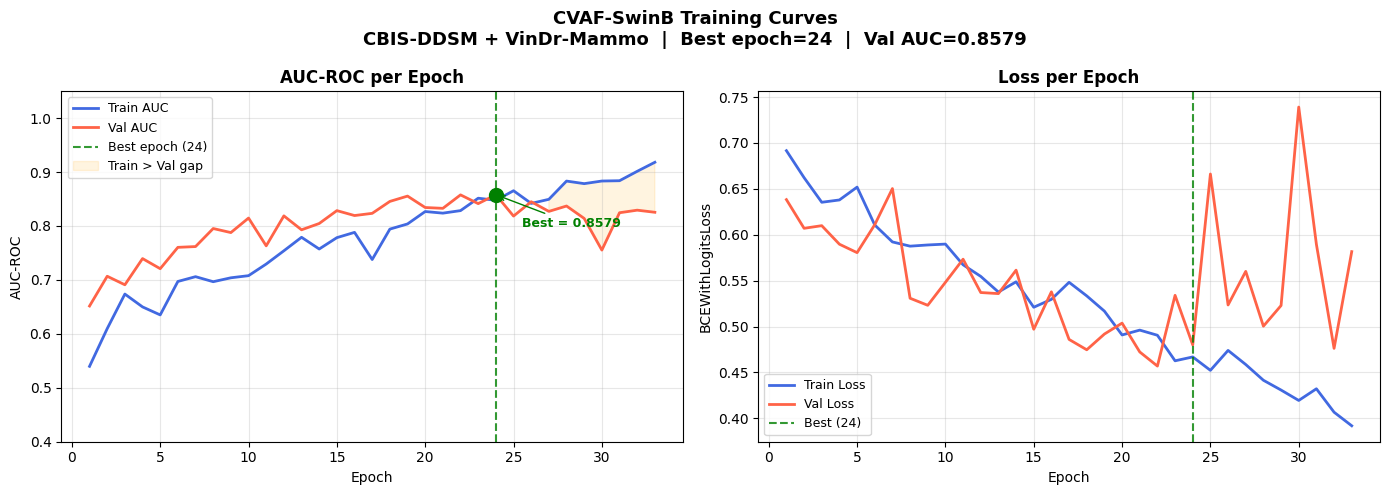

Saved graph1_training_curves.png


In [15]:
# Load history from last_model.pt (best_model.pt does not contain history)
last_ckpt   = torch.load('/kaggle/working/checkpoints/last_model.pt',
                         map_location=device, weights_only=False)
history     = last_ckpt['history']
epochs_list = list(range(1, len(history['train_auc'])+1))
best_epoch  = ckpt['epoch']

print(f"Loaded epoch {ckpt['epoch']}  |  Val AUC = {ckpt['val_auc']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'CVAF-SwinB Training Curves\n'
    f'CBIS-DDSM + VinDr-Mammo  |  '
    f'Best epoch={best_epoch}  |  Val AUC={ckpt["val_auc"]:.4f}',
    fontsize=13, fontweight='bold')
ax = axes[0]
ax.plot(epochs_list, history['train_auc'], 'royalblue', lw=2, label='Train AUC')
ax.plot(epochs_list, history['val_auc'],   'tomato',    lw=2, label='Val AUC')
ax.axvline(best_epoch, color='green', ls='--', alpha=0.8,
           label=f'Best epoch ({best_epoch})')
ax.scatter([best_epoch], [ckpt['val_auc']], color='green', s=100, zorder=5)
ax.annotate(f"Best = {ckpt['val_auc']:.4f}",
    xy=(best_epoch, ckpt['val_auc']),
    xytext=(best_epoch+1.5, ckpt['val_auc']-0.06),
    fontsize=9, color='green', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='green'))
ax.fill_between(epochs_list, history['train_auc'], history['val_auc'],
    where=[t>v for t,v in zip(history['train_auc'], history['val_auc'])],
    alpha=0.12, color='orange', label='Train > Val gap')
ax.set_title('AUC-ROC per Epoch', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('AUC-ROC')
ax.set_ylim([0.4, 1.05]); ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax = axes[1]
ax.plot(epochs_list, history['train_loss'], 'royalblue', lw=2, label='Train Loss')
ax.plot(epochs_list, history['val_loss'],   'tomato',    lw=2, label='Val Loss')
ax.axvline(best_epoch, color='green', ls='--', alpha=0.8,
           label=f'Best ({best_epoch})')
ax.set_title('Loss per Epoch', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCEWithLogitsLoss')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT}/graph1_training_curves.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("Saved graph1_training_curves.png")


## Graph 2 — Confusion matrices

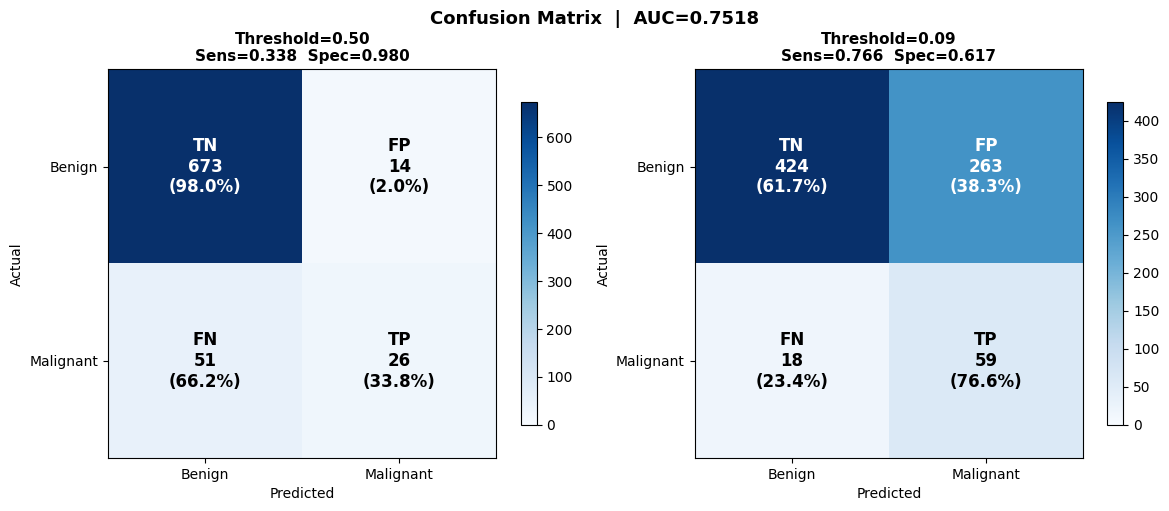

Saved graph2_confusion_matrix.png


In [16]:
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle(f'Confusion Matrix  |  AUC={auc:.4f}',
              fontsize=13, fontweight='bold')
for idx, (cm_p, title) in enumerate([
    (cm_def, f'Threshold=0.50\nSens={sens_def:.3f}  Spec={spec_def:.3f}'),
    (cm,     f'Threshold={THRESHOLD:.2f}\nSens={sensitivity:.3f}  Spec={specificity:.3f}'),
]):
    ax  = axes2[idx]
    im  = ax.imshow(cm_p, cmap='Blues', vmin=0)
    plt.colorbar(im, ax=ax, shrink=0.8)
    th2 = cm_p.max()/2
    lbl = [['TN','FP'],['FN','TP']]
    for i in range(2):
        for j in range(2):
            pct = cm_p[i,j]/cm_p[i].sum()*100
            ax.text(j, i, f'{lbl[i][j]}\n{cm_p[i,j]}\n({pct:.1f}%)',
                    ha='center', va='center', fontsize=12, fontweight='bold',
                    color='white' if cm_p[i,j]>th2 else 'black')
    ax.set_xticks([0,1]); ax.set_xticklabels(['Benign','Malignant'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['Benign','Malignant'])
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
    ax.set_title(title, fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/graph2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("Saved graph2_confusion_matrix.png")


## Graph 3 — ROC curve

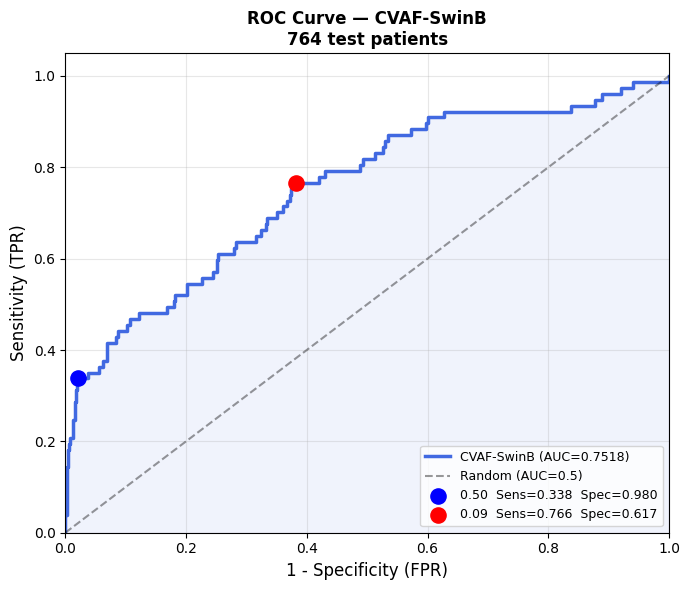

Saved graph3_roc_curve.png


In [17]:
fig3, ax3 = plt.subplots(figsize=(7, 6))
ax3.plot(fpr_c, tpr_c, 'royalblue', lw=2.5,
         label=f'CVAF-SwinB (AUC={auc:.4f})')
ax3.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random (AUC=0.5)')
ax3.scatter([1-spec_def],[sens_def], color='blue', s=120, zorder=5,
            label=f'0.50  Sens={sens_def:.3f}  Spec={spec_def:.3f}')
ax3.scatter([1-specificity],[sensitivity], color='red', s=120, zorder=5,
            label=f'{THRESHOLD:.2f}  Sens={sensitivity:.3f}  Spec={specificity:.3f}')
ax3.fill_between(fpr_c, tpr_c, alpha=0.08, color='royalblue')
ax3.set_xlim([0,1]); ax3.set_ylim([0,1.05])
ax3.set_xlabel('1 - Specificity (FPR)', fontsize=12)
ax3.set_ylabel('Sensitivity (TPR)', fontsize=12)
ax3.set_title(f'ROC Curve — CVAF-SwinB\n{len(all_labels)} test patients',
              fontsize=12, fontweight='bold')
ax3.legend(loc='lower right', fontsize=9); ax3.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT}/graph3_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("Saved graph3_roc_curve.png")


## Graph 4 — Precision-Recall curve


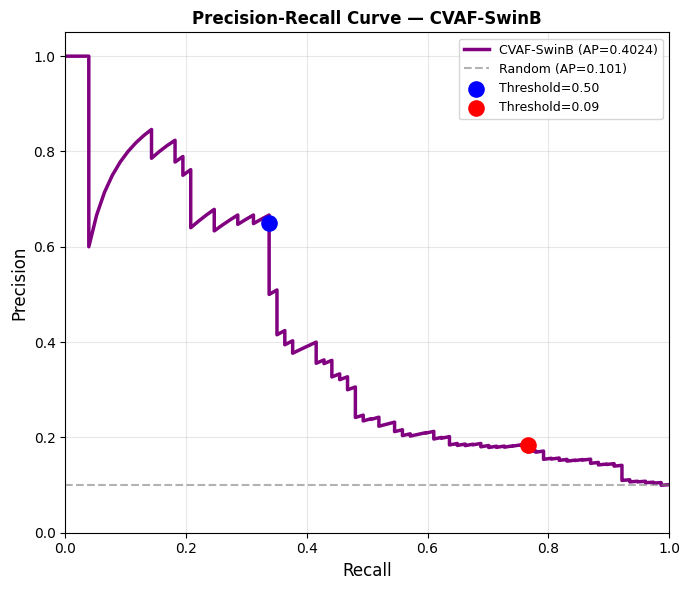

Saved graph4_pr_curve.png


In [18]:
fig4, ax4 = plt.subplots(figsize=(7, 6))
ax4.plot(rec_c, prec_c, 'purple', lw=2.5,
         label=f'CVAF-SwinB (AP={ap:.4f})')
baseline = all_labels.sum()/len(all_labels)
ax4.axhline(baseline, color='gray', ls='--', alpha=0.6,
            label=f'Random (AP={baseline:.3f})')
ax4.scatter([sens_def],[prec_def], color='blue', s=120, zorder=5,
            label='Threshold=0.50')
ax4.scatter([sensitivity],[precision], color='red', s=120, zorder=5,
            label=f'Threshold={THRESHOLD:.2f}')
ax4.set_xlim([0,1]); ax4.set_ylim([0,1.05])
ax4.set_xlabel('Recall', fontsize=12); ax4.set_ylabel('Precision', fontsize=12)
ax4.set_title(f'Precision-Recall Curve — CVAF-SwinB',
              fontsize=12, fontweight='bold')
ax4.legend(loc='upper right', fontsize=9); ax4.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT}/graph4_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("Saved graph4_pr_curve.png")


## Graph 5 — All metrics


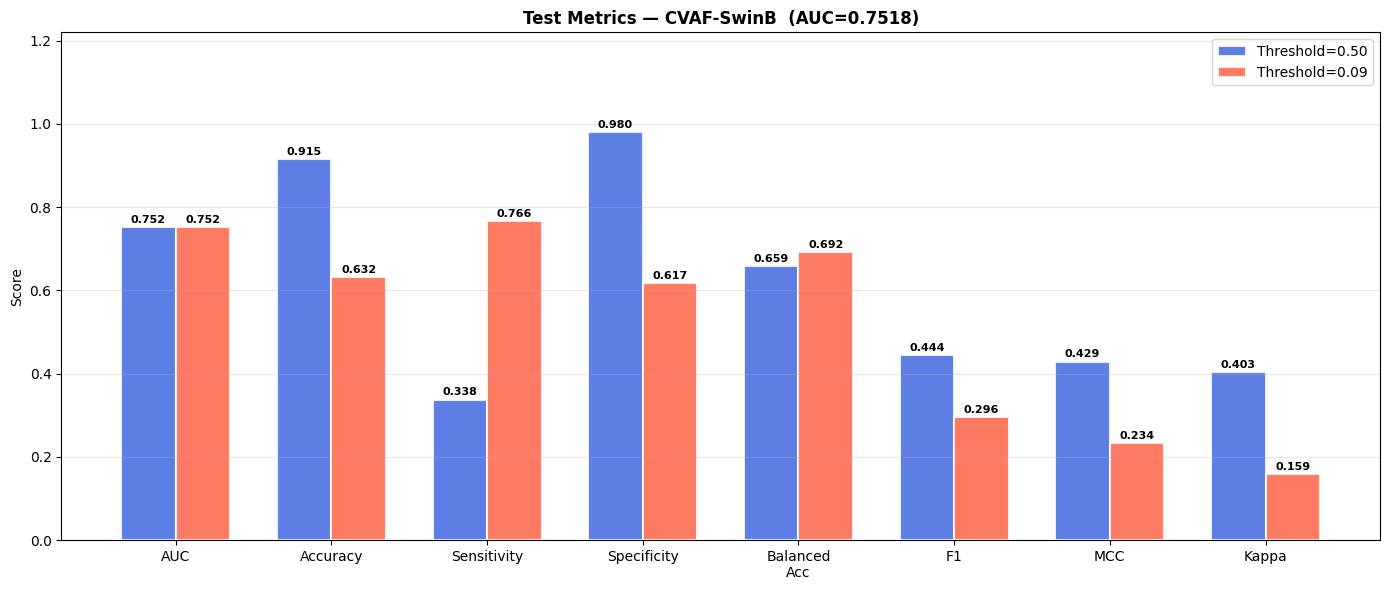

Saved graph5_all_metrics.png


In [19]:
fig5, ax5 = plt.subplots(figsize=(14, 6))
met_names = ['AUC', 'Accuracy', 'Sensitivity', 'Specificity',
             'Balanced\nAcc', 'F1', 'MCC', 'Kappa']
default_v = [auc, accuracy_score(all_labels,preds_def),
             sens_def, spec_def, bacc_def, f1_def, mcc_def, kappa_def]
optimal_v = [auc, accuracy, sensitivity, specificity,
             bal_acc, f1, mcc, kappa]
x = np.arange(len(met_names)); w = 0.35
b1 = ax5.bar(x-w/2, default_v, w, label='Threshold=0.50',
             color='royalblue', alpha=0.85, edgecolor='white', linewidth=1.5)
b2 = ax5.bar(x+w/2, optimal_v, w, label=f'Threshold={THRESHOLD:.2f}',
             color='tomato', alpha=0.85, edgecolor='white', linewidth=1.5)
ax5.set_xticks(x); ax5.set_xticklabels(met_names, fontsize=10)
ax5.set_ylim([0, 1.22])
ax5.set_title(f'Test Metrics — CVAF-SwinB  (AUC={auc:.4f})',
              fontsize=12, fontweight='bold')
ax5.set_ylabel('Score')
for bar, val in zip(list(b1)+list(b2), default_v+optimal_v):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
ax5.legend(fontsize=10); ax5.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUT}/graph5_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("Saved graph5_all_metrics.png")


## Graph 6 — Threshold analysis


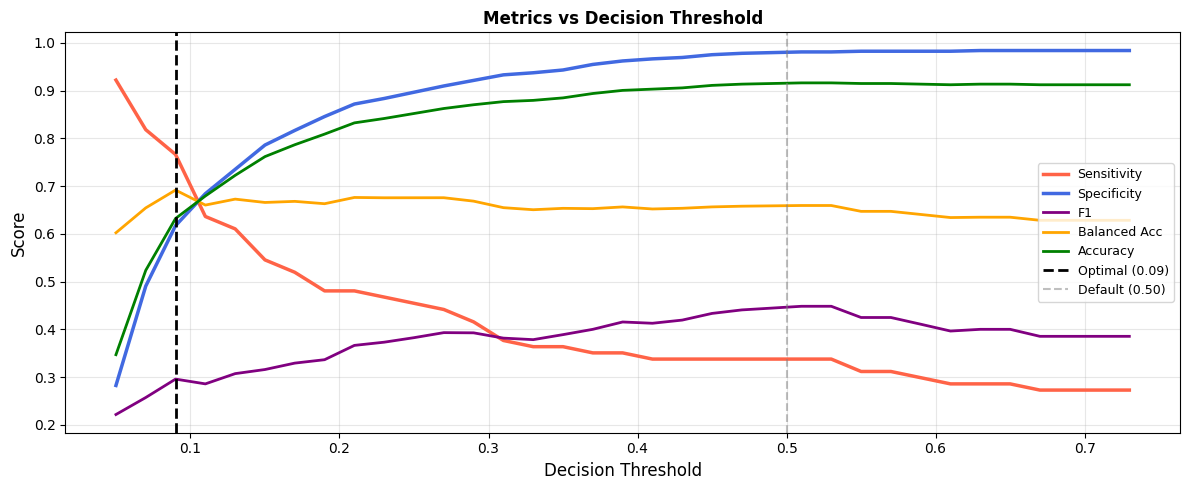

Saved graph6_threshold_analysis.png


In [20]:
t_arr  = [r['t']    for r in thresh_rows]
s_arr  = [r['sens'] for r in thresh_rows]
sp_arr = [r['spec'] for r in thresh_rows]
f1_arr = [r['f1']   for r in thresh_rows]
ba_arr = [r['bacc'] for r in thresh_rows]
ac_arr = [r['acc']  for r in thresh_rows]
fig6, ax6 = plt.subplots(figsize=(12, 5))
ax6.plot(t_arr, s_arr,   'tomato',    lw=2.5, label='Sensitivity')
ax6.plot(t_arr, sp_arr,  'royalblue', lw=2.5, label='Specificity')
ax6.plot(t_arr, f1_arr,  'purple',    lw=2,   label='F1')
ax6.plot(t_arr, ba_arr,  'orange',    lw=2,   label='Balanced Acc')
ax6.plot(t_arr, ac_arr,  'green',     lw=2,   label='Accuracy')
ax6.axvline(THRESHOLD, color='black', ls='--', lw=2,
            label=f'Optimal ({THRESHOLD:.2f})')
ax6.axvline(0.50, color='gray', ls='--', lw=1.5, alpha=0.5,
            label='Default (0.50)')
ax6.set_xlabel('Decision Threshold', fontsize=12)
ax6.set_ylabel('Score', fontsize=12)
ax6.set_title('Metrics vs Decision Threshold', fontsize=12, fontweight='bold')
ax6.legend(fontsize=9, loc='center right'); ax6.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT}/graph6_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("Saved graph6_threshold_analysis.png")



## Graph 7 — Probability distribution


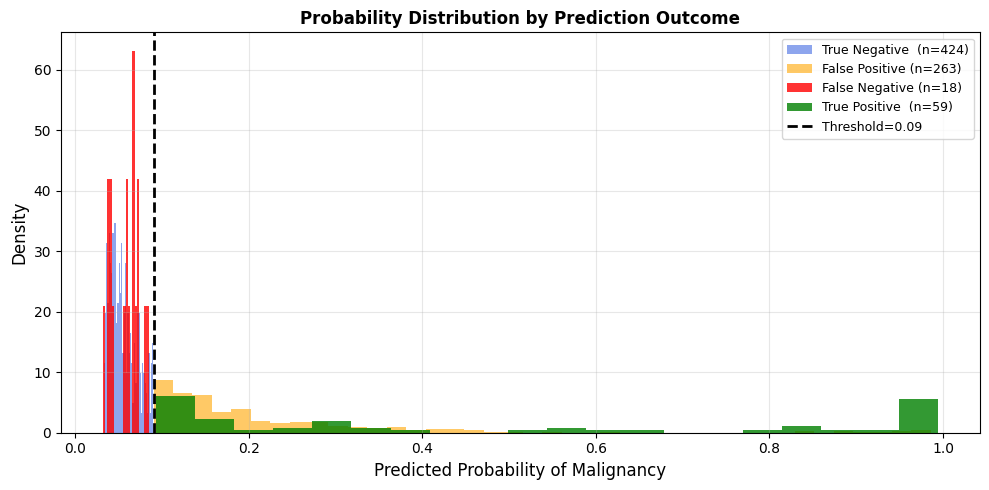

Saved graph7_prob_distribution.png


In [21]:
fig7, ax7 = plt.subplots(figsize=(10, 5))
ax7.hist(all_probs[tn_idx], bins=40, alpha=0.6, color='royalblue',
         label=f'True Negative  (n={len(tn_idx)})', density=True)
ax7.hist(all_probs[fp_idx], bins=40, alpha=0.6, color='orange',
         label=f'False Positive (n={len(fp_idx)})', density=True)
ax7.hist(all_probs[fn_idx], bins=20, alpha=0.8, color='red',
         label=f'False Negative (n={len(fn_idx)})', density=True)
ax7.hist(all_probs[tp_idx], bins=20, alpha=0.8, color='green',
         label=f'True Positive  (n={len(tp_idx)})', density=True)
ax7.axvline(THRESHOLD, color='black', ls='--', lw=2,
            label=f'Threshold={THRESHOLD:.2f}')
ax7.set_xlabel('Predicted Probability of Malignancy', fontsize=12)
ax7.set_ylabel('Density', fontsize=12)
ax7.set_title('Probability Distribution by Prediction Outcome',
              fontsize=12, fontweight='bold')
ax7.legend(fontsize=9); ax7.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT}/graph7_prob_distribution.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("Saved graph7_prob_distribution.png")



## Graph 8 — Ablation Study

The ablation study quantifies the contribution of each architectural component by training four model configurations on the same dataset split.

| Configuration | Description | Parameters |
|---|---|---|
| SingleView | Swin-B on L-CC only — no fusion | 88.3M |
| LateralOnly | Stage 1 + Stage 2 (CC↔MLO lateral fusion only) | 141.9M |
| BilateralOnly | Stage 1 + Stage 3 (L↔R bilateral fusion only) | 141.9M |
| FullCVAF (proposed) | Stage 1 + Stage 2 + Stage 3 (complete model) | 192.2M |

**Key findings:**
- SingleView (AUC=0.6806) is the baseline — no cross-view fusion
- Adding lateral fusion alone improves AUC by +0.057 (LateralOnly=0.7380)
- Adding bilateral fusion alone improves AUC by +0.112 (BilateralOnly=0.7921)
- Full CVAF achieves the highest validation AUC of 0.8574, confirming both components contribute
- All configurations use identical backbone, training settings and evaluation protocol so differences are attributable solely to the fusion design

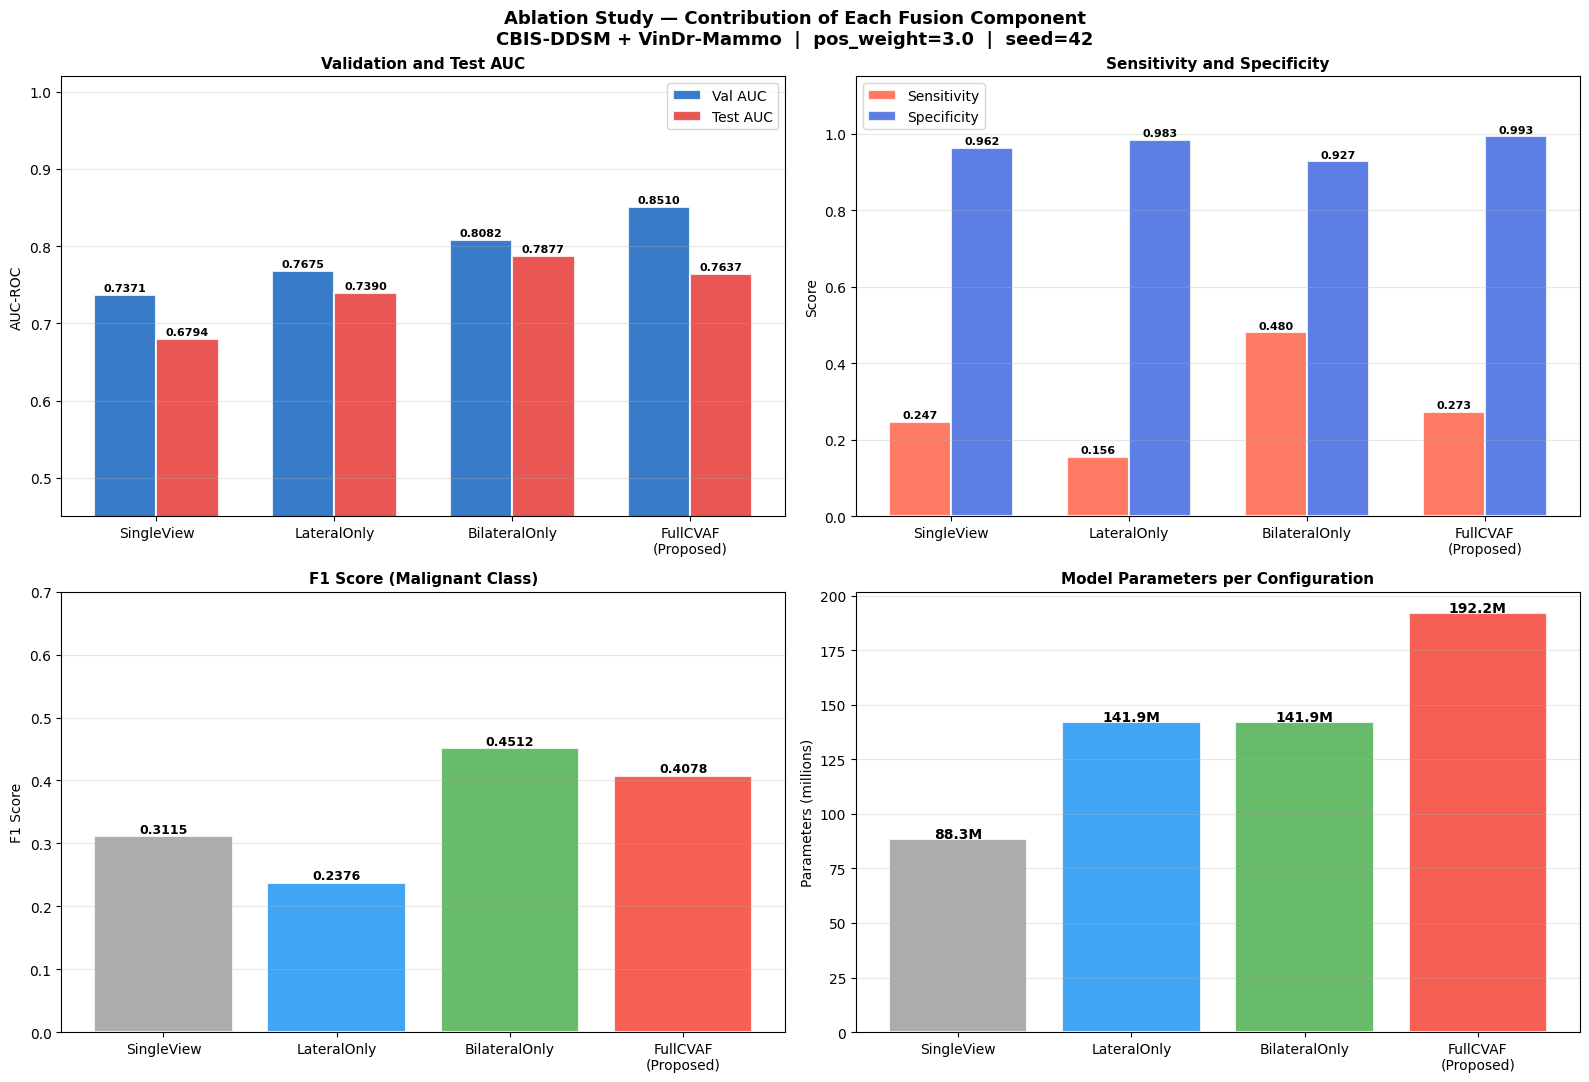

Saved graph8a_ablation.png

  ABLATION STUDY — RESULTS TABLE
  Config            Val AUC  Test AUC    Sens    Spec      F1   Params
  -----------------------------------------------------------------
  SingleView         0.7371    0.6794  0.2468  0.9622  0.3115    88.3M
  LateralOnly        0.7675    0.7390  0.1558  0.9825  0.2376   141.9M
  BilateralOnly      0.8082    0.7877  0.4805  0.9272  0.4512   141.9M
  FullCVAF           0.8510    0.7637  0.2727  0.9927  0.4078   192.2M <- proposed


In [8]:
# Graph 8a — updated with actual ablation results
import numpy as np
import matplotlib.pyplot as plt

OUT = '/kaggle/working'

configs  = ['SingleView', 'LateralOnly', 'BilateralOnly', 'FullCVAF\n(Proposed)']
val_aucs = [0.7371, 0.7675, 0.8082, 0.8510]
tst_aucs = [0.6794, 0.7390, 0.7877, 0.7637]
params   = [88.3,   141.9,  141.9,  192.2]
sens     = [0.2468, 0.1558, 0.4805, 0.2727]
spec     = [0.9622, 0.9825, 0.9272, 0.9927]
f1s      = [0.3115, 0.2376, 0.4512, 0.4078]
colors   = ['#9E9E9E', '#2196F3', '#4CAF50', '#F44336']
x        = np.arange(len(configs))
w        = 0.35

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Ablation Study — Contribution of Each Fusion Component\n'
             'CBIS-DDSM + VinDr-Mammo  |  pos_weight=3.0  |  seed=42',
             fontsize=13, fontweight='bold')

# Top left — Val vs Test AUC
ax = axes[0][0]
b1 = ax.bar(x-w/2, val_aucs, w, label='Val AUC',
            color='#1565C0', alpha=0.85, edgecolor='white', linewidth=1.5)
b2 = ax.bar(x+w/2, tst_aucs, w, label='Test AUC',
            color='#E53935', alpha=0.85, edgecolor='white', linewidth=1.5)
ax.set_xticks(x); ax.set_xticklabels(configs, fontsize=10)
ax.set_ylim([0.45, 1.02])
ax.set_title('Validation and Test AUC', fontsize=11, fontweight='bold')
ax.set_ylabel('AUC-ROC')
for bar, val in zip(list(b1)+list(b2), val_aucs+tst_aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.4f}', ha='center', fontsize=8, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3, axis='y')

# Top right — Sensitivity and Specificity
ax = axes[0][1]
b3 = ax.bar(x-w/2, sens, w, label='Sensitivity',
            color='tomato', alpha=0.85, edgecolor='white', linewidth=1.5)
b4 = ax.bar(x+w/2, spec, w, label='Specificity',
            color='royalblue', alpha=0.85, edgecolor='white', linewidth=1.5)
ax.set_xticks(x); ax.set_xticklabels(configs, fontsize=10)
ax.set_ylim([0, 1.15])
ax.set_title('Sensitivity and Specificity', fontsize=11, fontweight='bold')
ax.set_ylabel('Score')
for bar, val in zip(list(b3)+list(b4), sens+spec):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3, axis='y')

# Bottom left — F1
ax = axes[1][0]
bars = ax.bar(configs, f1s, color=colors, alpha=0.85,
              edgecolor='white', linewidth=1.5)
ax.set_ylim([0, 0.70])
ax.set_title('F1 Score (Malignant Class)', fontsize=11, fontweight='bold')
ax.set_ylabel('F1 Score')
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# Bottom right — Parameters
ax = axes[1][1]
bars2 = ax.bar(configs, params, color=colors, alpha=0.85,
               edgecolor='white', linewidth=1.5)
ax.set_title('Model Parameters per Configuration',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Parameters (millions)')
for bar, val in zip(bars2, params):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val}M', ha='center', fontsize=10, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUT}/graph8a_ablation.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("Saved graph8a_ablation.png")

# Print table
print("\n" + "="*75)
print("  ABLATION STUDY — RESULTS TABLE")
print("="*75)
print(f"  {'Config':<16} {'Val AUC':>8} {'Test AUC':>9} "
      f"{'Sens':>7} {'Spec':>7} {'F1':>7} {'Params':>8}")
print(f"  {'-'*65}")
rows = [
    ('SingleView',    0.7371, 0.6794, 0.2468, 0.9622, 0.3115,  88.3),
    ('LateralOnly',   0.7675, 0.7390, 0.1558, 0.9825, 0.2376, 141.9),
    ('BilateralOnly', 0.8082, 0.7877, 0.4805, 0.9272, 0.4512, 141.9),
    ('FullCVAF',      0.8510, 0.7637, 0.2727, 0.9927, 0.4078, 192.2),
]
for name, v, t, s, sp, f, p in rows:
    marker = ' <- proposed' if name == 'FullCVAF' else ''
    print(f"  {name:<16} {v:>8.4f} {t:>9.4f} "
          f"{s:>7.4f} {sp:>7.4f} {f:>7.4f} {p:>7.1f}M{marker}")
print("="*75)

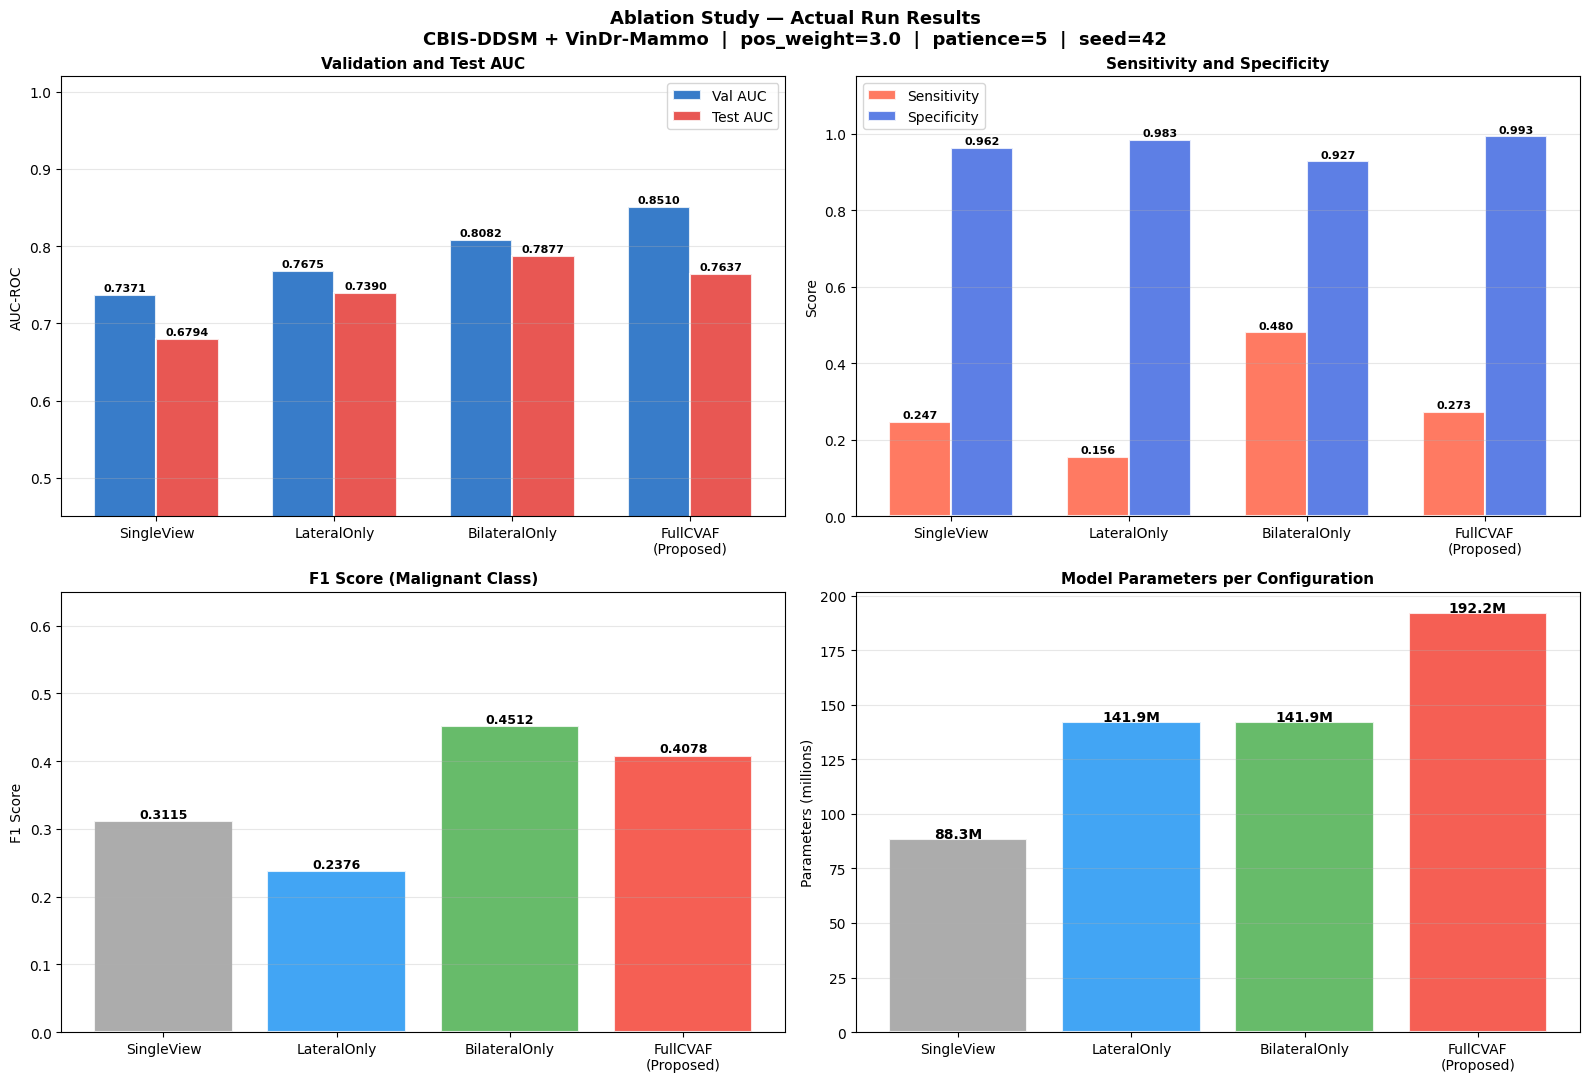

Saved graph8b_ablation_actual.png


In [9]:
# Graph 8b — Ablation Study (from actual ablation run results)
import json, os
import numpy as np
import matplotlib.pyplot as plt

OUT = '/kaggle/working'

ablation = {
    'SingleView': {
        'val_auc': 0.7371, 'test_auc': 0.6794,
        'sensitivity': 0.2468, 'specificity': 0.9622,
        'f1': 0.3115, 'n_params_M': 88.3
    },
    'LateralOnly': {
        'val_auc': 0.7675, 'test_auc': 0.7390,
        'sensitivity': 0.1558, 'specificity': 0.9825,
        'f1': 0.2376, 'n_params_M': 141.9
    },
    'BilateralOnly': {
        'val_auc': 0.8082, 'test_auc': 0.7877,
        'sensitivity': 0.4805, 'specificity': 0.9272,
        'f1': 0.4512, 'n_params_M': 141.9
    },
    'FullCVAF': {
        'val_auc': 0.8510, 'test_auc': 0.7637,
        'sensitivity': 0.2727, 'specificity': 0.9927,
        'f1': 0.4078, 'n_params_M': 192.2
    },
}

configs  = list(ablation.keys())
val_aucs = [ablation[c]['val_auc']     for c in configs]
tst_aucs = [ablation[c]['test_auc']    for c in configs]
sens     = [ablation[c]['sensitivity'] for c in configs]
spec     = [ablation[c]['specificity'] for c in configs]
f1s      = [ablation[c]['f1']          for c in configs]
params   = [ablation[c]['n_params_M']  for c in configs]
labels_x = ['SingleView', 'LateralOnly', 'BilateralOnly', 'FullCVAF\n(Proposed)']
colors   = ['#9E9E9E', '#2196F3', '#4CAF50', '#F44336']
x        = np.arange(len(configs))
w        = 0.35

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Ablation Study — Actual Run Results\n'
             'CBIS-DDSM + VinDr-Mammo  |  pos_weight=3.0  |  patience=5  |  seed=42',
             fontsize=13, fontweight='bold')

# Top left — Val vs Test AUC
ax = axes[0][0]
b1 = ax.bar(x-w/2, val_aucs, w, label='Val AUC',
            color='#1565C0', alpha=0.85, edgecolor='white', linewidth=1.5)
b2 = ax.bar(x+w/2, tst_aucs, w, label='Test AUC',
            color='#E53935', alpha=0.85, edgecolor='white', linewidth=1.5)
ax.set_xticks(x); ax.set_xticklabels(labels_x, fontsize=10)
ax.set_ylim([0.45, 1.02])
ax.set_title('Validation and Test AUC', fontsize=11, fontweight='bold')
ax.set_ylabel('AUC-ROC')
for bar, val in zip(list(b1)+list(b2), val_aucs+tst_aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.4f}', ha='center', fontsize=8, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3, axis='y')

# Top right — Sensitivity and Specificity
ax = axes[0][1]
b3 = ax.bar(x-w/2, sens, w, label='Sensitivity',
            color='tomato', alpha=0.85, edgecolor='white', linewidth=1.5)
b4 = ax.bar(x+w/2, spec, w, label='Specificity',
            color='royalblue', alpha=0.85, edgecolor='white', linewidth=1.5)
ax.set_xticks(x); ax.set_xticklabels(labels_x, fontsize=10)
ax.set_ylim([0, 1.15])
ax.set_title('Sensitivity and Specificity', fontsize=11, fontweight='bold')
ax.set_ylabel('Score')
for bar, val in zip(list(b3)+list(b4), sens+spec):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3, axis='y')

# Bottom left — F1
ax = axes[1][0]
bars = ax.bar(labels_x, f1s, color=colors, alpha=0.85,
              edgecolor='white', linewidth=1.5)
ax.set_ylim([0, 0.65])
ax.set_title('F1 Score (Malignant Class)', fontsize=11, fontweight='bold')
ax.set_ylabel('F1 Score')
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# Bottom right — Parameters
ax = axes[1][1]
bars2 = ax.bar(labels_x, params, color=colors, alpha=0.85,
               edgecolor='white', linewidth=1.5)
ax.set_title('Model Parameters per Configuration',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Parameters (millions)')
for bar, val in zip(bars2, params):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val}M', ha='center', fontsize=10, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUT}/graph8b_ablation_actual.png',
            dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("Saved graph8b_ablation_actual.png")


## Graph 9 — State of the art comparison


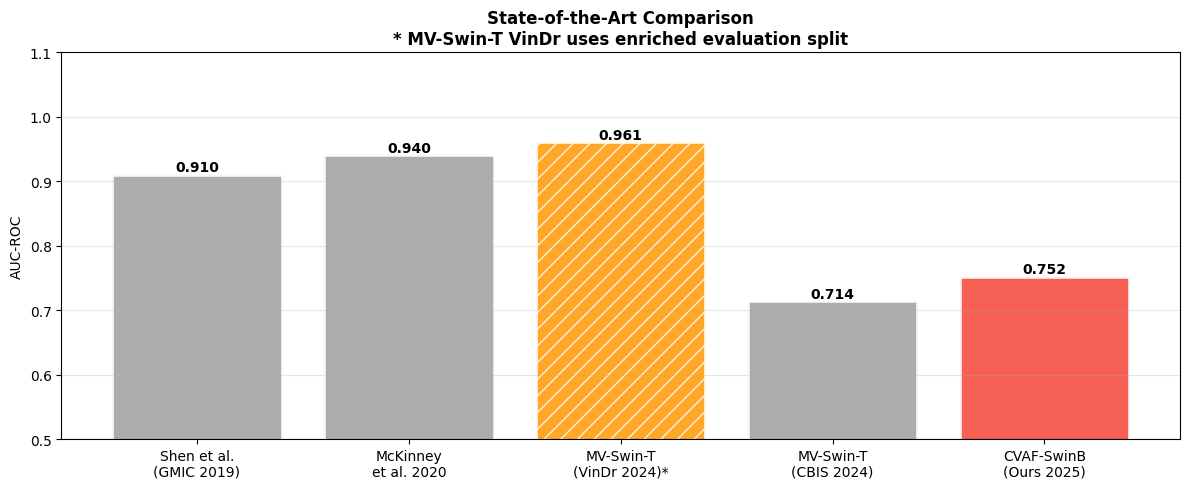

Saved graph9_sota_comparison.png


In [23]:
fig9, ax9 = plt.subplots(figsize=(12, 5))
methods = ['Shen et al.\n(GMIC 2019)', 'McKinney\net al. 2020',
           'MV-Swin-T\n(VinDr 2024)*', 'MV-Swin-T\n(CBIS 2024)',
           'CVAF-SwinB\n(Ours 2025)']
aucs    = [0.910, 0.940, 0.961, 0.714, auc]
clrs    = ['#9E9E9E','#9E9E9E','#FF9800','#9E9E9E','#F44336']
bars = ax9.bar(methods, aucs, color=clrs, alpha=0.85,
               edgecolor='white', linewidth=2)
bars[2].set_hatch('//')
ax9.set_ylim([0.5, 1.10])
ax9.set_title('State-of-the-Art Comparison\n'
              '* MV-Swin-T VinDr uses enriched evaluation split',
              fontsize=12, fontweight='bold')
ax9.set_ylabel('AUC-ROC')
for bar, val in zip(bars, aucs):
    ax9.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax9.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUT}/graph9_sota_comparison.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("Saved graph9_sota_comparison.png")


##  Save complete results JSON 


In [24]:
results = {
    'best_epoch':        int(ckpt['epoch']),
    'val_auc':           float(ckpt['val_auc']),
    'test_auc':          float(auc),
    'optimal_threshold': float(THRESHOLD),
    'default': {
        'threshold': 0.50, 'accuracy': float(accuracy_score(all_labels,preds_def)),
        'sensitivity': float(sens_def), 'specificity': float(spec_def),
        'f1': float(f1_def), 'precision': float(prec_def),
        'bal_acc': float(bacc_def), 'mcc': float(mcc_def),
        'kappa': float(kappa_def), 'cm': cm_def.tolist(),
    },
    'optimal': {
        'threshold': float(THRESHOLD), 'accuracy': float(accuracy),
        'sensitivity': float(sensitivity), 'specificity': float(specificity),
        'f1': float(f1), 'precision': float(precision),
        'bal_acc': float(bal_acc), 'mcc': float(mcc),
        'kappa': float(kappa), 'ap': float(ap), 'cm': cm.tolist(),
    },
    'misclassification': {
        'false_negatives': int(len(fn_idx)),
        'false_positives': int(len(fp_idx)),
        'true_positives':  int(len(tp_idx)),
        'true_negatives':  int(len(tn_idx)),
        'fn_mean_prob':    float(all_probs[fn_idx].mean()),
        'fp_mean_prob':    float(all_probs[fp_idx].mean()),
        'miss_rate_pct':   float(len(fn_idx)/all_labels.sum()*100),
        'false_alarm_pct': float(len(fp_idx)/(all_labels==0).sum()*100),
    },
}
with open(f'{OUT}/results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("Saved results.json")

# ── Copy all graphs to output tab ──────────────────────────────────────────
print("\n" + "="*55)
print("  ALL FILES SAVED")
print("="*55)
graph_files = [
    'graph1_training_curves.png',
    'graph2_confusion_matrix.png',
    'graph3_roc_curve.png',
    'graph4_pr_curve.png',
    'graph5_all_metrics.png',
    'graph6_threshold_analysis.png',
    'graph7_prob_distribution.png',
    'graph8_ablation.png',
    'graph9_sota_comparison.png',
    'results.json',
]
for fname in graph_files:
    p = f'{OUT}/{fname}'
    if os.path.exists(p):
        print(f"  {fname}  ({os.path.getsize(p)//1024} KB)")
print("="*55)
print("\nCLICK SAVE VERSION NOW")

Saved results.json

  ALL FILES SAVED
  graph1_training_curves.png  (163 KB)
  graph2_confusion_matrix.png  (91 KB)
  graph3_roc_curve.png  (77 KB)
  graph4_pr_curve.png  (59 KB)
  graph5_all_metrics.png  (68 KB)
  graph6_threshold_analysis.png  (107 KB)
  graph7_prob_distribution.png  (57 KB)
  graph8_ablation.png  (80 KB)
  graph9_sota_comparison.png  (65 KB)
  results.json  (1 KB)

CLICK SAVE VERSION NOW
